The goal of this notebook is to figure out how to calculate the infall times of subhalos onto "massive progenitors" and onto the "main host"
Main goals:
* t_infall_anything_bigger = time or snapshot when the subhalo under scrutiny falls into *any* more massive object (massive progenitor or main host). This would be "first_infall_snap" in the Symphony halo-level data (don't know where exactly yet).
* t_infall_main_host = time when the subhalo under scrutiny falls into *specifically* the main host. This would be "merger_snap" in the Symphony halo-level data, in the "hist" (time-independent) data.
* t_disrupt = time when the subhalo under scrutiny falls below the density required for ROCKSTAR to designate it a subhalo (300 particles)

Using these:
* Create probability density functions (basically histograms) where the infall times are sorted into time bins, allowing us to see if/when the distribution of infall times is peaked and how it behaves across different mass ranges. It would be good to make one version that is not normalized to host formation time, and another that is.
* Create a plot using an autocorrelation function to measure how correlated the infall times of the "massive progenitor" are with the other subhalos (both field and associated I assume? This is the one I'm less clear on). It may also be useful to have a version that shows this effect but for different lines of sight. Autocorrelation should be giving a characteristic time interval for subhalo infalls.
* Calculate the "preprocessed fraction," in other words the number of subhalos that fall onto something else before falling onto the MW, divided by the total number
* Make a plot comparing the location/slope of the SHMF (before and after a particular massive infall), and the other side showing the change in the subhalo count of the massive infalls (GSE, LMC). Would be good to put side-by-side.
* Cross-correlation function (?)

In [1]:
## packages and globals

import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from matplotlib import colormaps
import matplotlib.colors as mcolors
from symlib.util import DEFAULT_HALO_NAMES

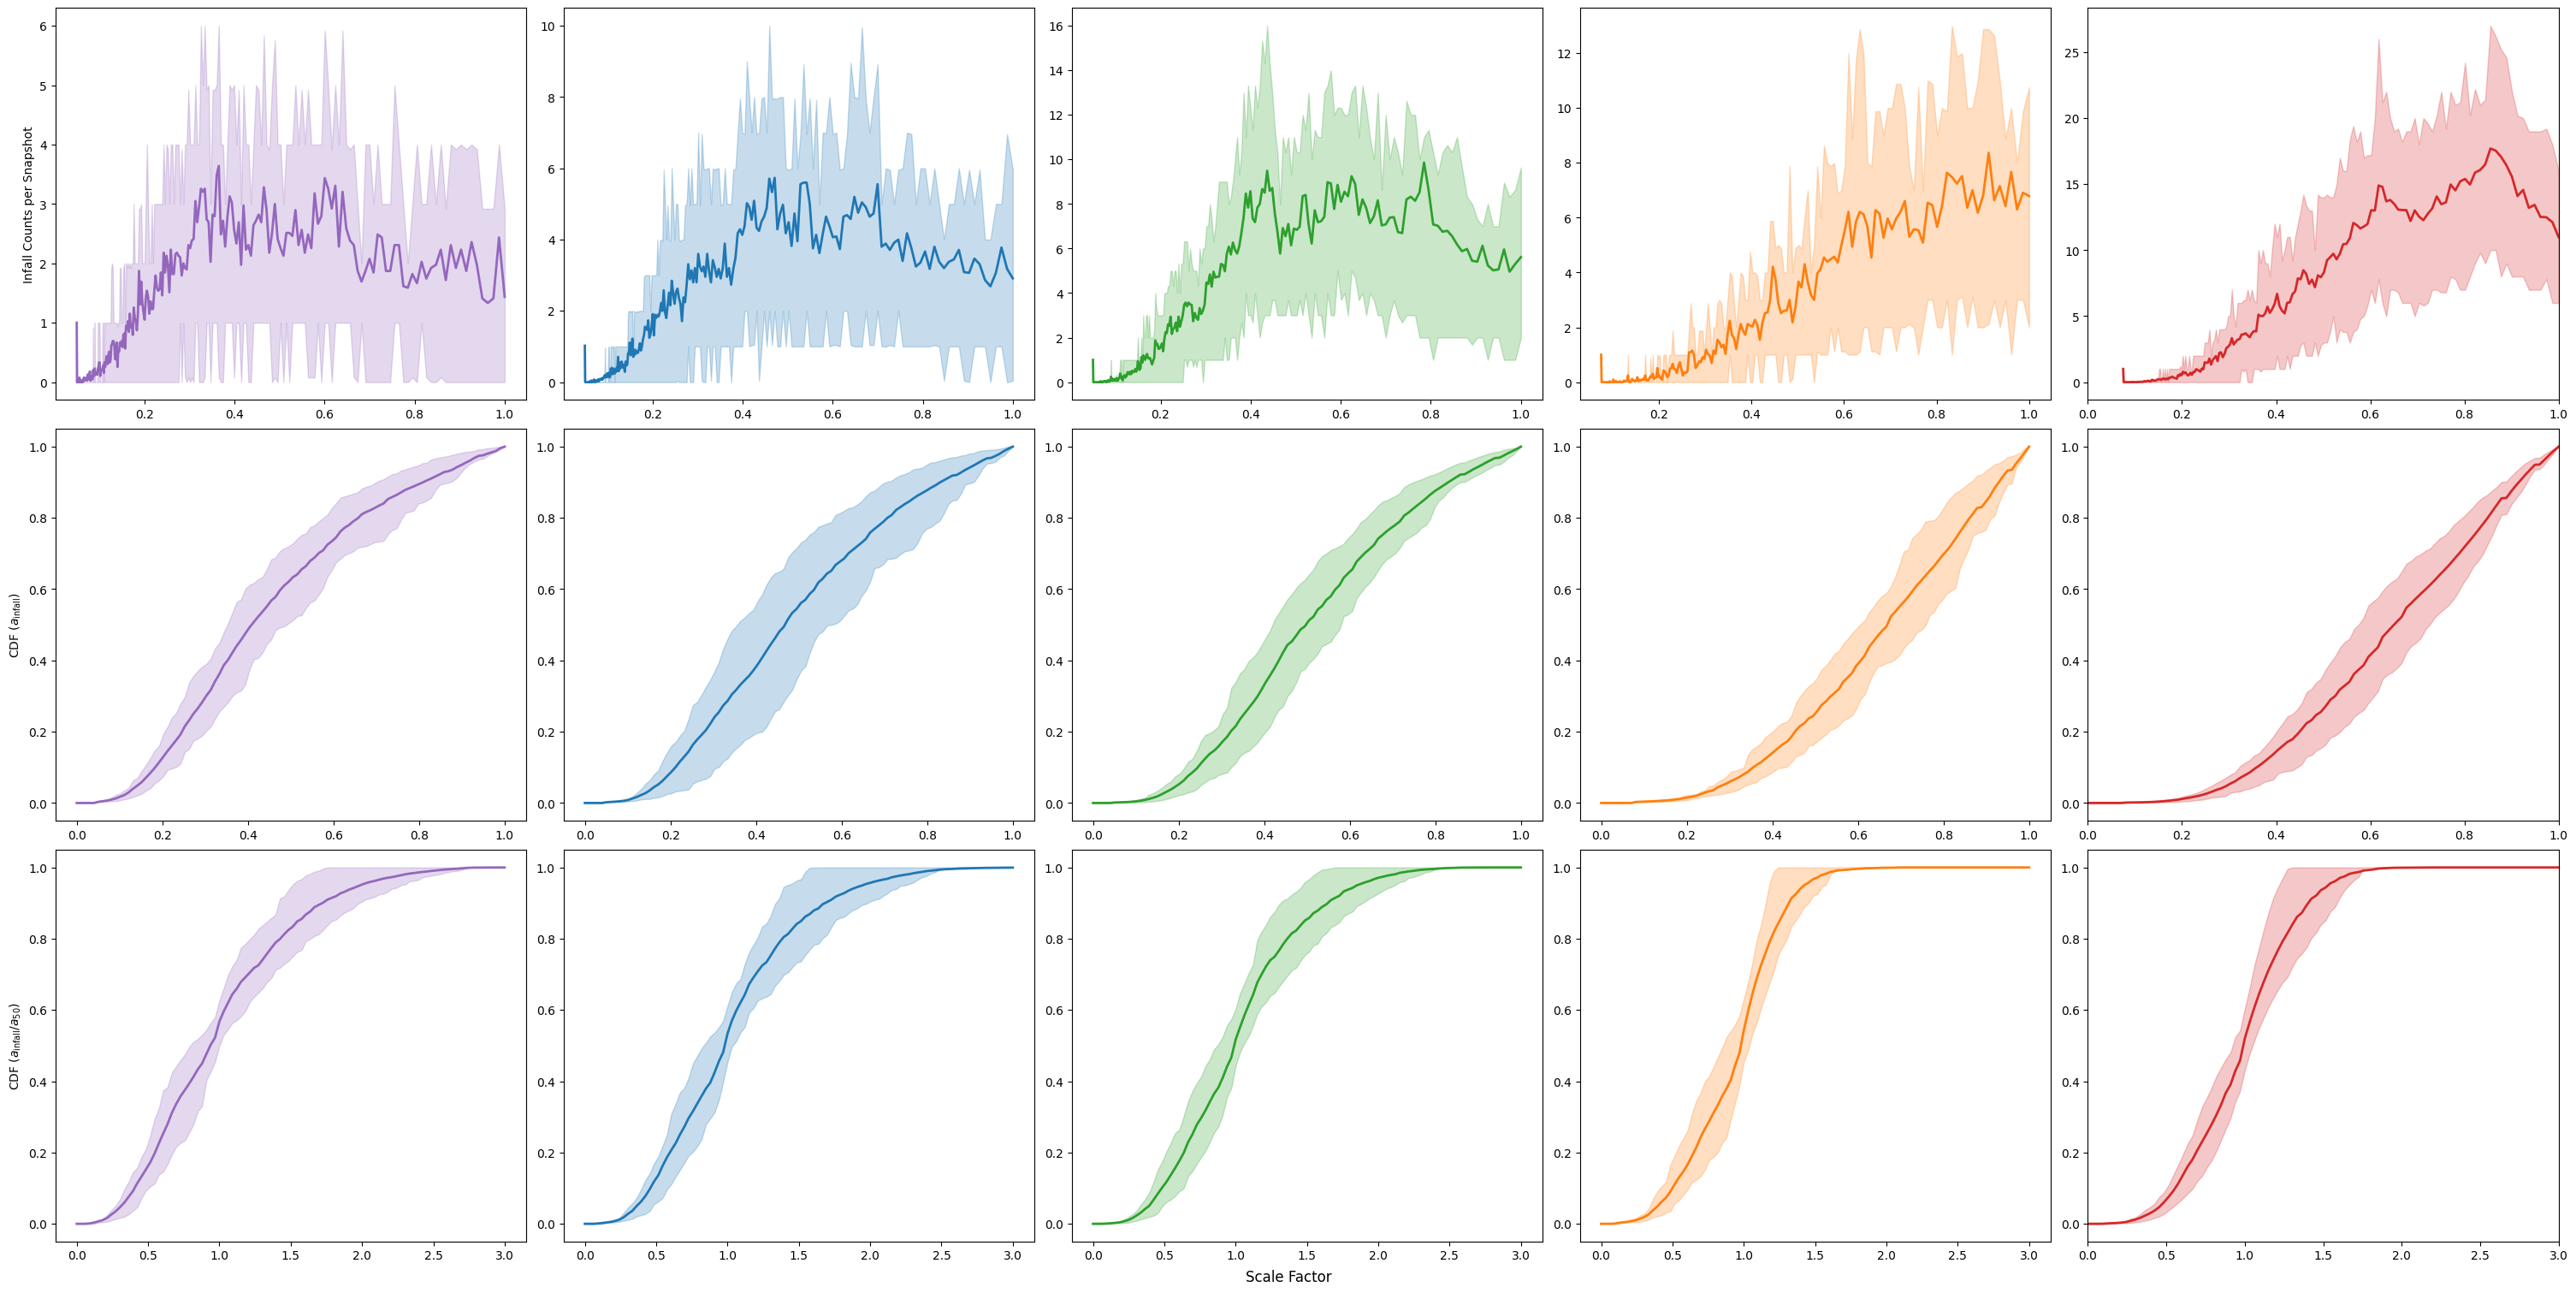

In [32]:
## GLOBALS
base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

#suite_list = ["SymphonyLMC", "SymphonyMilkyWay"]
#colors = ["tab:purple", "tab:blue"]


ncols = len(suite_list)
#ncols = 1
nrows = 3


fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (6 * ncols, 5 * nrows),
                       sharex = False, constrained_layout = True, squeeze = False)

############################################################################################################

# CDF HELPER FUNCTION
def compute_cdf(values, grid):
    values = np.sort(values)
    if len(values) == 0:
        return np.zeros_like(grid)
    cdf = np.arange(1, len(values) + 1) / len(values)
    return np.interp(grid, values, cdf, left=0, right=1)


# UNIFIED CDF STATS HELPER
def compute_cdf_stats(data_list, grid):

    cdf_stack = []

    for a in data_list:
        if len(a) == 0:
            continue

        a_clean = a[np.isfinite(a)]
        if len(a_clean) == 0:
            continue

        cdf_stack.append(compute_cdf(a_clean, grid))

    cdf_stack = np.array(cdf_stack)

    if cdf_stack.shape[0] == 0:
        return cdf_stack, None, None, None

    mean = np.mean(cdf_stack, axis=0)
    p16 = np.percentile(cdf_stack, 16, axis=0)
    p84 = np.percentile(cdf_stack, 84, axis=0)

    return cdf_stack, mean, p16, p84
    
############################################################################################################

## grids for later
a_grid_raw = np.linspace(0, 1, 100)
a_grid_norm = np.linspace(0, 3, 100)

## MAIN LOOP
for suite_index, suite in enumerate(suite_list):

    halo_names = DEFAULT_HALO_NAMES[suite]

    sim_dir0 = symlib.get_host_directory(base_dir, suite, 0)
    scale_factors = symlib.scale_factors(sim_dir0)
    nbins_snap = len(scale_factors)

    raw_counts_all = []
    all_a_infalls_raw = []
    all_a_infalls_norm = []

    
    # LOOP OVER HALOS
    for halo_index, halo_name in enumerate(halo_names):

        sim_dir = symlib.get_host_directory(base_dir, suite, halo_index)
        h, hist = symlib.read_subhalos(sim_dir)

        merger_snap = hist["merger_snap"]
        valid = merger_snap >= 0
        valid_snap = merger_snap[valid]

        a_infall_raw = scale_factors[valid_snap]

        mvir = h["mvir"][0, :]
        peak_mass = np.max(mvir)

        mass_50_snap = np.where(mvir >= 0.5 * peak_mass)[0]
        if len(mass_50_snap) == 0:
            continue

        a50 = scale_factors[mass_50_snap[0]]

        all_a_infalls_raw.append(a_infall_raw)
        all_a_infalls_norm.append(a_infall_raw / a50)

        counts = np.zeros(nbins_snap)
        unique_snaps, snap_counts = np.unique(valid_snap, return_counts=True)
        counts[unique_snaps] = snap_counts

        raw_counts_all.append(counts)

    raw_counts_all = np.array(raw_counts_all)

    ############################################################################################################
    
    ## ROW 1: RAW COUNTS

    raw_mean = np.mean(raw_counts_all, axis=0)
    raw_p16 = np.percentile(raw_counts_all, 16, axis=0)
    raw_p84 = np.percentile(raw_counts_all, 84, axis=0)

    ax[0, suite_index].fill_between(scale_factors, raw_p16, raw_p84, color = colors[suite_index], alpha = 0.25)
    ax[0, suite_index].plot(scale_factors, raw_mean, color = colors[suite_index], lw = 2)

    ############################################################################################################
    
    ## ROW 2: RAW CDF

    _, cdf_mean, cdf_p16, cdf_p84 = compute_cdf_stats(all_a_infalls_raw, a_grid_raw)

    if cdf_mean is not None:
        ax[1, suite_index].fill_between(a_grid_raw, cdf_p16, cdf_p84, color = colors[suite_index], alpha = 0.25)
        ax[1, suite_index].plot(a_grid_raw, cdf_mean, color = colors[suite_index], lw = 2)

    ############################################################################################################
    
    ## ROW 3: NORMALIZED CDF

    _, cdf_mean_norm, cdf_p16_norm, cdf_p84_norm = compute_cdf_stats(all_a_infalls_norm, a_grid_norm)

    if cdf_mean_norm is not None:
        ax[2, suite_index].fill_between(a_grid_norm, cdf_p16_norm, cdf_p84_norm, color = colors[suite_index], alpha = 0.25)
        ax[2, suite_index].plot(a_grid_norm, cdf_mean_norm, color = colors[suite_index], lw = 2)

############################################################################################################


############################################################################################################
## SCALING AND LABELS

# Row 1: raw counts vs scale factor
ax[0, suite_index].set_xlim(0, 1)

# Row 2: raw infall CDF vs scale factor
ax[1, suite_index].set_xlim(0, 1)

# Row 3: normalized infall CDF vs a_infall / a50
ax[2, suite_index].set_xlim(0, 3)

ax[0, 0].set_ylabel("Infall Counts per Snapshot")
ax[1, 0].set_ylabel(r"CDF ($a_{\rm infall}$)")
ax[2, 0].set_ylabel(r"CDF ($a_{\rm infall}/a_{50}$)")

fig.supxlabel("Scale Factor")

plt.savefig("CDFs over infall times.png")
plt.show()